In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import mikeio
from mikeio.eum import EUMType, EUMUnit

ds = xr.open_dataset(r"D:\Phd Research\Data\Wind data\hurricane_harvey_2017_wind.nc")
ds

<xarray.Dataset>
Dimensions:     (valid_time: 168, latitude: 12, longitude: 13)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2017-08-24 ... 2017-08-30T23:00:00
  * latitude    (latitude) float64 28.87 28.62 28.37 28.12 ... 26.62 26.37 26.12
  * longitude   (longitude) float64 -97.85 -97.6 -97.35 ... -95.35 -95.1 -94.85
    expver      (valid_time) object ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 ...
    v10         (valid_time, latitude, longitude) float32 ...
    msl         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-11-19T18:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
ds["u10"]

<xarray.DataArray 'u10' (valid_time: 168, latitude: 12, longitude: 13)>
array([[[-4.39116 , -4.19304 , ..., -3.233567, -3.830369],
        [-3.862473, -3.590379, ..., -3.907273, -4.517747],
        ...,
        [-5.90764 , -5.989915, ..., -6.239549, -6.247361],
        [-6.046311, -6.123582, ..., -6.392015, -6.624681]],

       [[-3.564676, -3.779154, ..., -3.645975, -4.599466],
        [-3.609354, -3.779398, ..., -4.410624, -4.506937],
        ...,
        [-4.739725, -4.769144, ..., -6.268534, -5.889505],
        [-4.856302, -4.869852, ..., -6.104471, -6.039652]],

       ...,

       [[ 1.897833,  2.030401, ...,  4.78797 ,  6.049932],
        [ 2.165167,  2.291388, ...,  5.48255 ,  6.24085 ],
        ...,
        [-0.138056, -2.57873 , ...,  6.150274,  6.585089],
        [-0.602167, -3.123163, ...,  5.644659,  6.058966]],

       [[ 1.147057,  1.241783, ...,  3.684166,  4.811119],
        [ 1.457848,  1.555748, ...,  4.401207,  4.845787],
        ...,
        [-2.394447, -4.427162, ...,  5.491539,  5.977867],
        [-2.857338, -4.838295, ...,  4.976402,  5.392418]]], dtype=float32)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 2017-08-24 ... 2017-08-30T23:00:00
  * latitude    (latitude) float64 28.87 28.62 28.37 28.12 ... 26.62 26.37 26.12
  * longitude   (longitude) float64 -97.85 -97.6 -97.35 ... -95.35 -95.1 -94.85
    expver      (valid_time) object '0001' '0001' '0001' ... '0001' '0001'
Attributes:
    GRIB_paramId:                             165
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      156
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    GRIB_NV:                                  0
    GRIB_Nx:                                  13
    GRIB_Ny:                                  12
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           u10
    GRIB_gridDefinitionDescription:           Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees:        0.25
    GRIB_iScansNegatively:                    0
    GRIB_jDirectionIncrementInDegrees:        0.25
    GRIB_jPointsAreConsecutive:               0
    GRIB_jScansPositively:                    0
    GRIB_latitudeOfFirstGridPointInDegrees:   28.87
    GRIB_latitudeOfLastGridPointInDegrees:    26.12
    GRIB_longitudeOfFirstGridPointInDegrees:  -97.85
    GRIB_longitudeOfLastGridPointInDegrees:   -94.85
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                10 metre U wind component
    GRIB_shortName:                           10u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [3]:
ds0 = ds.isel(valid_time=0)
ds0

<xarray.Dataset>
Dimensions:     (latitude: 12, longitude: 13)
Coordinates:
    number      int64 0
    valid_time  datetime64[ns] 2017-08-24
  * latitude    (latitude) float64 28.87 28.62 28.37 28.12 ... 26.62 26.37 26.12
  * longitude   (longitude) float64 -97.85 -97.6 -97.35 ... -95.35 -95.1 -94.85
    expver      object '0001'
Data variables:
    u10         (latitude, longitude) float32 -4.391 -4.193 ... -6.392 -6.625
    v10         (latitude, longitude) float32 3.476 3.271 ... -3.603 -2.851
    msl         (latitude, longitude) float32 1.01e+05 1.01e+05 ... 1.011e+05
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-11-19T18:40 GRIB to CDM+CF via cfgrib-0.9.1...

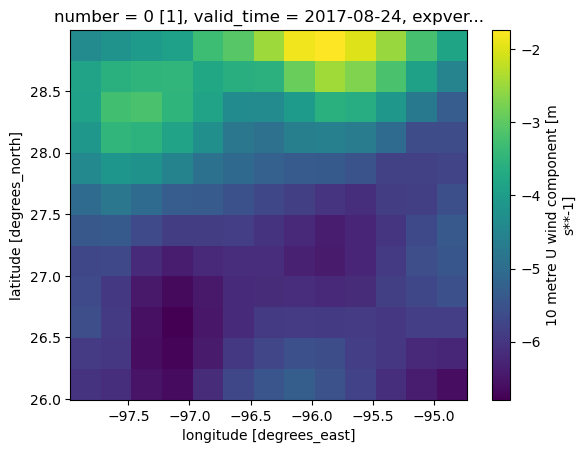

In [4]:
ds0.u10.plot()

In [5]:
ds_aoi = ds.sel(longitude=slice(-97.85,-94.61),
                latitude=slice(29,26.12)) # N -> S
ds_aoi

<xarray.Dataset>
Dimensions:     (valid_time: 168, latitude: 12, longitude: 13)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 2017-08-24 ... 2017-08-30T23:00:00
  * latitude    (latitude) float64 28.87 28.62 28.37 28.12 ... 26.62 26.37 26.12
  * longitude   (longitude) float64 -97.85 -97.6 -97.35 ... -95.35 -95.1 -94.85
    expver      (valid_time) object '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    u10         (valid_time, latitude, longitude) float32 -4.391 ... 5.392
    v10         (valid_time, latitude, longitude) float32 3.476 ... -0.9209
    msl         (valid_time, latitude, longitude) float32 1.01e+05 ... 1.011e+05
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-11-19T18:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
time = pd.DatetimeIndex(ds.valid_time)
time

DatetimeIndex(['2017-08-24 00:00:00', '2017-08-24 01:00:00',
               '2017-08-24 02:00:00', '2017-08-24 03:00:00',
               '2017-08-24 04:00:00', '2017-08-24 05:00:00',
               '2017-08-24 06:00:00', '2017-08-24 07:00:00',
               '2017-08-24 08:00:00', '2017-08-24 09:00:00',
               ...
               '2017-08-30 14:00:00', '2017-08-30 15:00:00',
               '2017-08-30 16:00:00', '2017-08-30 17:00:00',
               '2017-08-30 18:00:00', '2017-08-30 19:00:00',
               '2017-08-30 20:00:00', '2017-08-30 21:00:00',
               '2017-08-30 22:00:00', '2017-08-30 23:00:00'],
              dtype='datetime64[ns]', length=168, freq=None)

In [7]:
g = mikeio.Grid2D(x=ds_aoi.longitude, y=ds_aoi.latitude[::-1], projection="LONG/LAT")
g

<mikeio.Grid2D>
x: [-97.85, -97.6, ..., -94.85] (nx=13, dx=0.25)
y: [26.12, 26.37, ..., 28.87] (ny=12, dy=0.25)
projection: LONG/LAT

In [8]:
import mikeio

# Assuming time and geometry (g) are already defined, and ds_aoi is your dataset

das = [
    mikeio.DataArray(np.flip(ds_aoi.u10.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("u10", EUMType.Wind_Velocity, EUMUnit.meter_per_sec)),

    mikeio.DataArray(np.flip(ds_aoi.v10.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("v10", EUMType.Wind_Velocity, EUMUnit.meter_per_sec)),

    mikeio.DataArray(np.flip(ds_aoi.msl.values, axis=1),
                     time=time, geometry=g,
                     item=mikeio.ItemInfo("msl", EUMType.Air_Pressure, EUMUnit.hectopascal))
]


In [9]:
my_ds = mikeio.Dataset(das)
my_ds

<mikeio.Dataset>
dims: (time:168, y:12, x:13)
time: 2017-08-24 00:00:00 - 2017-08-30 23:00:00 (168 records)
geometry: Grid2D (ny=12, nx=13)
items:
  0:  u10 <Wind Velocity> (meter per sec)
  1:  v10 <Wind Velocity> (meter per sec)
  2:  msl <Air Pressure> (hectopascal)

In [10]:
my_ds.to_dfs("D:\Phd Research\Data\Wind data\Harvey_2017_August.dfs2")